In [1]:
# dependencies
import numpy as np
import matplotlib.pyplot as plt
# conversion factors
a0 = 5.29e-11 # Bohr radius in m
Eh = 4.36e-18 # Hartree energy in J
me = 9.109e-31 # electron mass in kg
mp = 1.673e-27 # proton mass in kg
uma = 1.66e-27 # atomic mass unit in kg
mass_factor = mp/me # mass factor to convert from uma to me

##  Lab 4 – Exploring free energy calculations using the Asymmetric Double-Well Potential 

In this lab, we will explore how to compute the free energy difference between two states, A and B, modeled by an asymmetric double-well potential.
We will express the partition function by separating the contributions from momentum and coordinates, allowing us to analyze the configurational dependence of the free energy in both states.
$$Z(\beta)=\frac{1}{h}\left ( \int_{-\infty}^{\infty}d\textbf{p}e^{-\beta \textbf{p}^{2}/ 2m}\right ) \left ( \int_{-\infty}^{\infty}d\textbf{x}e^{-\beta  U(\textbf{x})}\right ) \\
Z(\beta) = \frac{1}{h}Z_{IG}Z_{conf} $$



We can define the free energy difference between states $B$ and $C$ as $\Delta A_{B\to C} = -k_{B}T \ln {\frac{Z_{conf_{C}}}{Z_{conf_{B}}}}  $  Since the integration over all momenta can be performed analytically and contributes equally to both partition functions, thus the free energy difference can be estimated solely from the configurational part of the partition function.
(Demonstration: trivial.)


Therefore the Helmholtz Energy associated with this hipothetical reaction is: 
$$\Delta A_{B \to C} = -k_{B}T \ln {\frac{\int_{\tau_{C}}d\textbf{x}e^{-\beta U(\textbf{x})}}{\int_{\tau_{B}}d\textbf{x}e^{-\beta U(\textbf{x})}}}$$

where $\tau_{B}$ and $\tau_{C}$ correspond to the configurational space that define the state B and C respectively.

Considering the asymmetric double-well potential defined by:
$V(x) = a (x^{2} - b^{2})^{2} + cx$

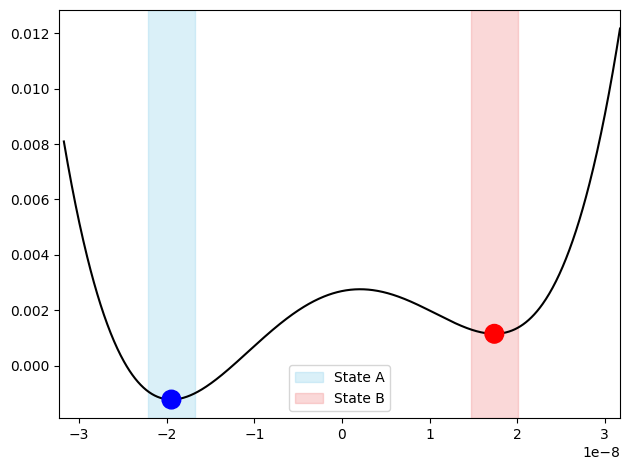

In [84]:
#load modules
from potentials import *
from walker import Trajectory1D
pot2 = create_potential("AsimmetricDoublewell", a=10e10, b=350*a0, c=10e7*a0**2) # create potential object
x = np.linspace(-600*a0, 600*a0, 1000)
Vx = pot2.V(x) 
plt.plot(x, Vx/Eh, color='black')
plt.xlim(-610*a0, 600*a0)

# Find the minima using SciPy library
# Bracket set the range where you expect each well
resA = minimize_scalar(pot2.V, bracket=(-60*a0, -50*a0))
resB = minimize_scalar(pot2.V, bracket=(50*a0, 60*a0))

xA, VA = resA.x, resA.fun / Eh
xB, VB = resB.x, resB.fun / Eh

# Shade the minima regions
plt.axvspan(xA-50*a0 , xA+50*a0 , color='skyblue', alpha=0.3, label='State A')
plt.axvspan(xB-50*a0 , xB+50*a0 , color='lightcoral', alpha=0.3, label='State B')

# Mark the minima points
plt.scatter([xA, xB], [VA, VB], color=['blue', 'red'], s=180, zorder=5)

plt.legend()
plt.tight_layout()
plt.show()

The above plot shows the asymmetric double-well potential with the identified minima marked and shaded regions indicating the states A and B.
Thus, the free energy difference between states A and B can be expressed as:
$\Delta A_{A\to B} = -k_{B}T \ln {\frac{Z_{conf_{B}}}{Z_{conf_{A}}}}  $
where $ \tau_{A}$  and  $\tau_{B} $ correspond to the configurational space that define the state A and B respectively and must to be selected manually.


In [85]:
kB = 1.38e-23 # Boltzmann constant in J/K
h = 6.626e-34  # Planck constant in Js
T = 100 # temperature in K
beta = 1/(kB*T) # atomic units of 1/J 

In [87]:
# --- Define integration regions ---
# You can choose a window around each minimum
width = 50 * a0
range_A = (x > xA - width) & (x < xA + width)
range_B = (x > xB - width) & (x < xB + width)

# --- Compute partition functions ---
ZA = np.trapz(np.exp(-beta * Vx[range_A]), x[range_A])
ZB = np.trapz(np.exp(-beta * Vx[range_B]), x[range_B])

# --- Free energy difference ---
DeltaA = -1 / beta * np.log(ZB / ZA)  # in j
DeltaA_kj_mol = DeltaA * (1e-3) * (6.022e23)  # convert to kJ/mol
print(f"Free energy difference ΔA (A to B): {DeltaA_kj_mol:.2f} kJ/mol")

Free energy difference ΔA (A to B): 6.18 kJ/mol


## SIMULATION OF THE ASYMMETRIC DOUBLE WELL POTENTIAL

Now we have calculated the free energy difference between states A and B using numerical integration over the defined regions around each minimum.
Next step is try to obtain similar results from a simulation using the ToyMD code.